<a href="https://colab.research.google.com/github/Lateephah/marketing-regression-analysis/blob/main/regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LOAD AND EXPLORE THE DATASET

In [1]:
# Here I imported all the necessary Libraries needed for the regression problem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [2]:
#Loading the dataset
df = pd.read_csv('/content/drive/MyDrive/3MTT Assessment Folder/Simple Linear Regression- Mini project/marketing_and_sales_data_evaluate_lr.csv')

In [3]:
df.head(5)

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


Just by looking at the five samples from the dataset, we can tell that we have Four columns (TV, Radio,Social_Media and	Sales and they are all numeric entries

In [4]:
df.shape

(4572, 4)

This tells us the shape or size of the dataset, they are 4572 data entries (rows) and 4 features (columns)

In [5]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


You get to see the 5 number summary of the data here, it provides a snapshot of the central tendency and spread of each variable in the dataset for TV, Radio, Social_Media, and Sales features.  
It includes the minimum, first quartile (25%), median (50%), third quartile (75%), and maximum values, along with mean and standard deviation for context.

Interpretation
- **TV** and **Sales** have wide ranges and high variability, indicating diverse spending and outcomes across campaigns.  
- **Radio** shows moderate spread, while **Social_Media** has the smallest range, suggesting more consistent but lower investment levels.  
- The median values closely align with the means, implying relatively symmetric distributions for most variables.  

In [6]:
df.duplicated().any()

np.False_

This means there are no duplicates in the dataset

#MISSING VALUES HANDLING

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


The dataset contains **4,572 entries** across 4 columns: TV, Radio, Social_Media, and Sales.  
- **TV** has 4,562 non-null values  
- **Radio** has 4,568 non-null values  
- **Social_Media** has 4,566 non-null values  
- **Sales** has 4,566 non-null values  

All columns are stored as `float64`, and the dataset size is approximately **143 KB**.  
This confirms the presence of a few missing values, which were addressed during the data cleaning phase and the exact missingness count is confirmed below


In [8]:
df.isnull().sum()

,0
TV,10
Radio,4
Social_Media,6
Sales,6


In [9]:
df[df.isnull().any(axis=1)]

,TV,Radio,Social_Media,Sales
13,NaN,22.351667,3.031815,276.165351
26,NaN,34.111674,4.624148,342.913372
46,NaN,34.859637,7.781417,318.969784
75,NaN,6.482293,0.866845,91.177216
99,NaN,7.635819,1.554146,56.186730
119,NaN,30.470485,6.806919,336.818690
141,NaN,9.164464,1.096681,65.259189
163,NaN,38.118424,6.676611,328.555184
182,81.0,26.425422,NaN,288.649441
183,NaN,1.287060,0.396179,56.545293


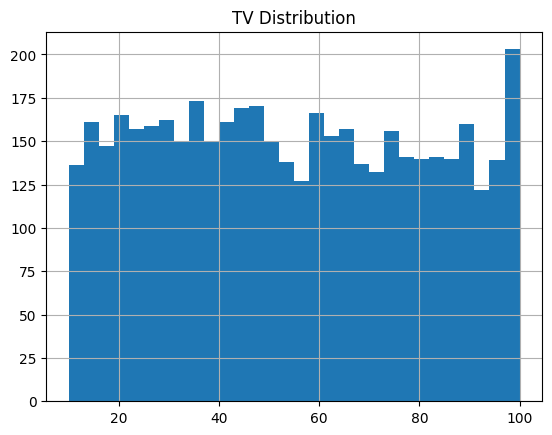

In [10]:
df['TV'].hist(bins=30)
plt.title("TV Distribution")
plt.show()


I chose **mean imputation** for handling missing values in the TV column because:
- The distribution of TV data is fairly symmetric with no strong skew or extreme outliers.
- Mean and median are very close in such cases, but using the mean preserves the overall average, which is important for regression and predictive modeling.
- With only 10 missing values out of 4,572 entries (~0.2%), **mean imputation** will not distort the dataset and ensures consistency across analyses.


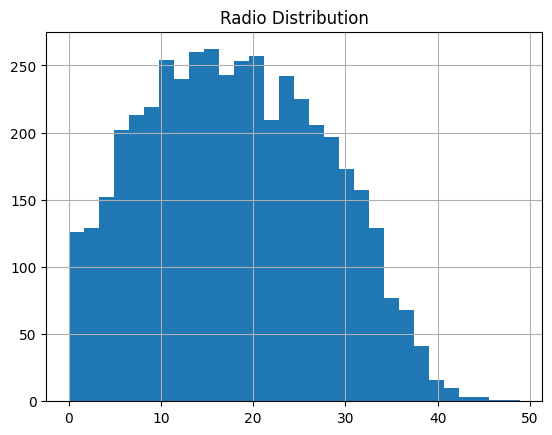

In [11]:
df['Radio'].hist(bins=30)
plt.title("Radio Distribution")
plt.show()

The Radio data shows a moderately **left-skewed distribution**, with most values concentrated between 10–25 and fewer observations at higher levels.  
Because the data is not perfectly symmetric, **median imputation** is preferred over mean imputation.  
The median is less affected by the tail of higher values and better represents the central tendency of the bulk of the data.

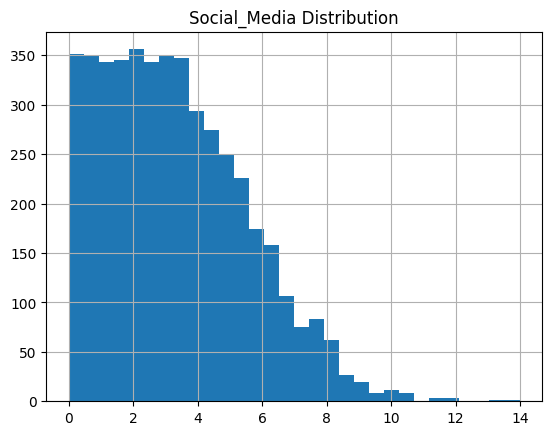

In [12]:
df['Social_Media'].hist(bins=30)
plt.title("Social_Media Distribution")
plt.show()

The Social_Media data is **strongly right-skewed**, with most values near zero and a long tail toward higher values.  
In this case, **median imputation** is more appropriate than mean imputation, since the mean would be pulled upward by the few large values.  
Median imputation preserves the typical behavior of the majority of observations.

In [13]:
df['TV'] = df['TV'].fillna(df['TV'].mean())
df['Radio'] = df['Radio'].fillna(df['Radio'].median())
df['Social_Media'] = df['Social_Media'].fillna(df['Social_Media'].median())

In [14]:
df.isnull().sum()

,0
TV,0
Radio,0
Social_Media,0
Sales,6


In [15]:
df = df.dropna(subset=['Sales'])

And the Sales column represents the **target variable** in the analysis so imputing its missing values can distort model training and evaluation, as the imputed values are not real observations. So instead, the rows with missing Sales values would be **dropped** and given that only 6 entries out of 4,572 is missing, dropping them would avoid introducing artificial bias.

In [16]:
df.isnull().sum()

,0
TV,0
Radio,0
Social_Media,0
Sales,0


#EXPLORATORY DATA ANALYSIS

Exploratory Data Analysis (EDA) is performed to further understand the structure of the dataset, uncover patterns, and identify relationships between advertising channels and sales.

##Univariate Analysis (Distribution)

Univariate analysis helps assess the distribution and spread of each variable before modeling.  
In a Marketing ROI analysis, understanding how advertising investments (TV, Radio, Social_Media) and Sales behave individually ensures that the data meets linear regression assumptions such as linearity, normality, and absence of extreme outliers.

Although some of these plots were explored earlier during the missing values and imputation steps, revisiting them together provides a more holistic view of the data.  
This helps evaluate the linearity of each predictor in relation to Sales and confirms that the dataset is well‑prepared for building a reliable linear regression model.


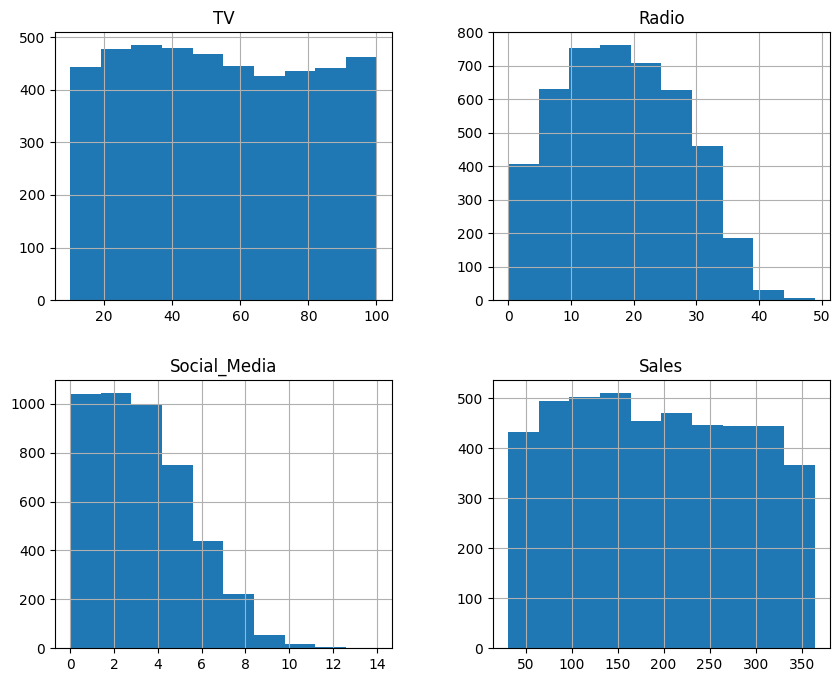

In [17]:
df.hist(figsize=(10, 8))
plt.show()

From the distribution plots:
- Like you have seen in previous plots **Radio** displays a moderate left‑skew, indicating most campaigns invest moderately in radio with fewer high‑spend cases.

- **Social_Media** is strongly right‑skewed, meaning most investments are small with a few large outliers.

-  **TV** and **Sales** show relatively uniform distributions, suggesting balanced spending and response levels across their ranges.

##Pairplot (Overall Relationships)

The pairplot provides a comprehensive view of the relationships among all variables: TV, Radio, Social_Media, and Sales.  
Each diagonal plot shows the distribution of a single variable, while the off-diagonal scatter plots reveal how variables relate to one another.


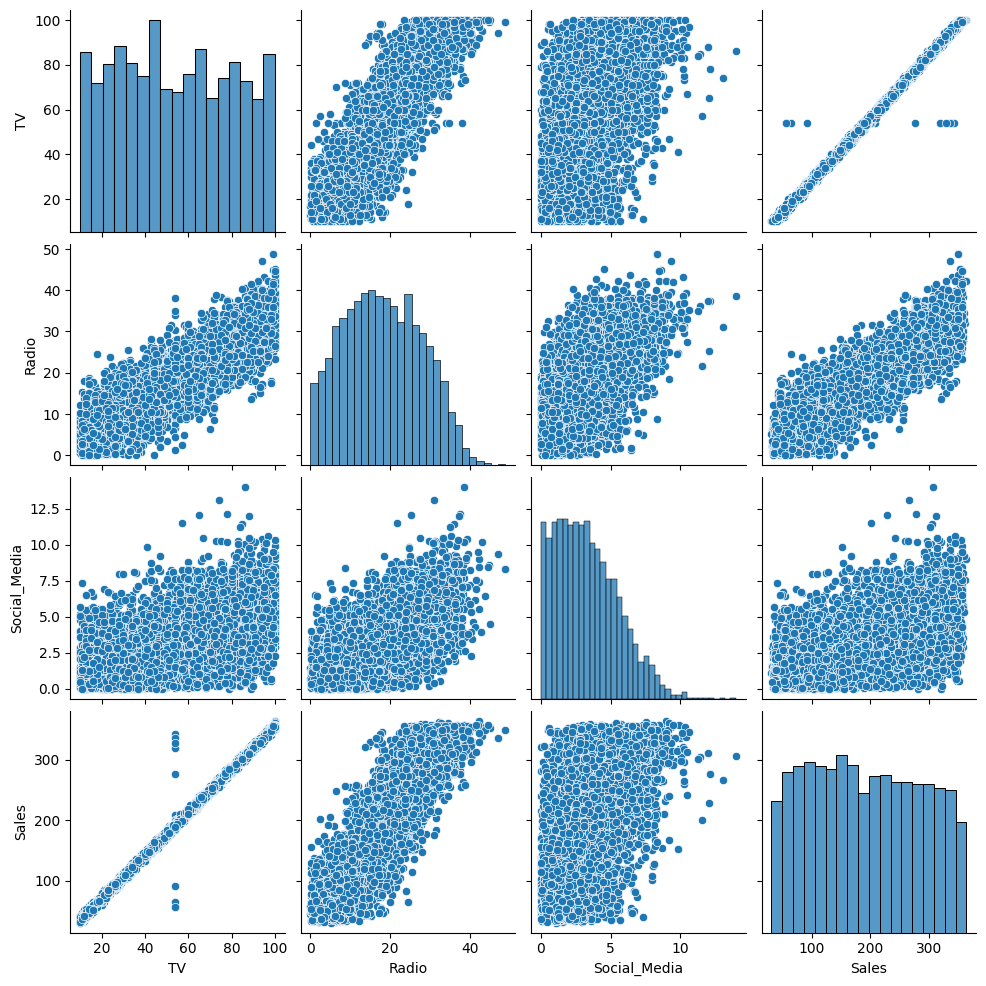

In [18]:
sns.pairplot(df)
plt.show()

From the pairplot:
- **TV vs Sales** shows a strong positive linear relationship, indicating that higher TV advertising budgets are associated with higher sales.
- **Radio vs Sales** and **Social_Media vs Sales** also show positive correlations, though weaker and more dispersed.
- The relationships among **TV, Radio, and Social_Media** suggest some overlap in marketing strategies but not perfect multicollinearity.

This visualization confirms that the predictors have meaningful linear relationships with Sales, supporting the suitability of a **Simple Linear Regression** model for Marketing ROI analysis.  
It also helps identify potential outliers and guides feature selection for further modeling.

##Correlation Matrix

The correlation matrix provides a numerical summary of how strongly each variable relates to the others.  
It complements the pairplot by quantifying the direction and strength of relationships between TV, Radio, Social_Media, and Sales.

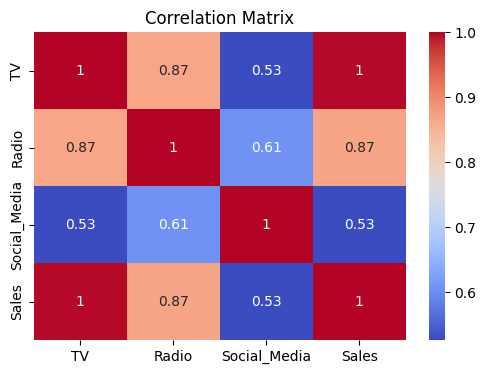

In [19]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Based on the correlation matrix, **TV** has the strongest relationship with Sales (correlation ≈ 1.00), followed by **Radio (0.87)** and **Social_Media (0.53)**.  
This finding is somewhat surprising, intuitively, one might expect Social Media to drive the highest ROI in modern marketing.  
However, the data suggests that traditional channels like TV and Radio still dominate sales influence, possibly because:
- TV remains a primary source of news and entertainment, reaching broad audiences.
- Radio captures attention during commutes and daily routines.
- Social Media, while interactive, may serve more for engagement and information sharing rather than direct purchase influence.

This insight highlights how consumer behavior and media consumption patterns can differ from assumptions, reinforcing the importance of data‑driven decision‑making in marketing ROI analysis.


#MODEL BUILDING

##Train-Test Split

In [20]:
#split the dataset into training and test sets; 80% training set and 20% Test Set
X = df[['TV']]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Add a constant to include the intercept
X_train_const = sm.add_constant(X_train)

# Build and fit the OLS model
ols_model = sm.OLS(y_train, X_train_const).fit()

In [22]:
# Residuals
residuals = ols_model.resid
fitted = ols_model.fittedvalues

 # Diagnostic plots to test Linearity, Normality, and Homoscedasticity

## 1. Linearity

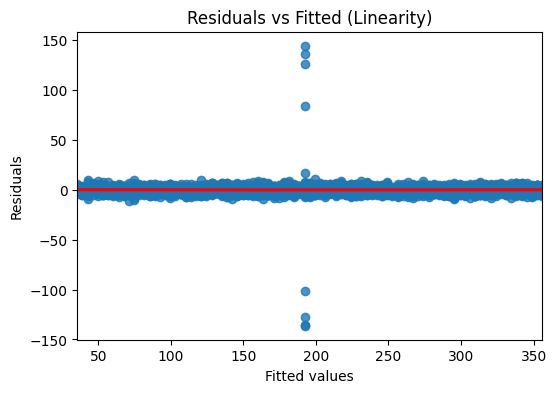

In [23]:
plt.figure(figsize=(6,4))
sns.residplot(x=fitted, y=residuals, lowess=True, line_kws={'color':'red'})
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Linearity)")
plt.show()


This plot checks whether the relationship between TV predictor and Sales is linear.  
The residuals are evenly scattered around the zero line, with no clear pattern, suggesting that the linearity assumption holds. A few outliers are visible, but they do not distort the overall trend.

## 2. Normality


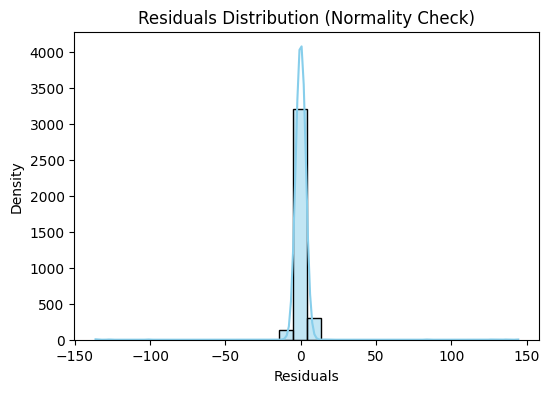

In [24]:
# Histogram with KDE (bell curve shape)
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=30, color="skyblue")
plt.title("Residuals Distribution (Normality Check)")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()


The  histogram of residuals with a kernel density estimate (KDE) provides a visual check for normality.  
- The residuals form an approximately **bell-shaped curve**, centered around zero.  
- The smooth KDE line highlights the distribution pattern, which closely resembles a normal distribution.  
- Minor deviations at the tails are visible, but overall the residuals approximate normality well.

This confirms that the normality assumption for OLS regression is reasonably satisfied.


## 3. Homoscedasticity

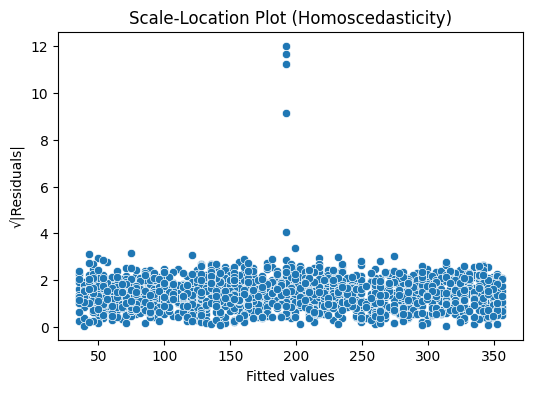

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=abs(residuals**0.5))
plt.xlabel("Fitted values")
plt.ylabel("√|Residuals|")
plt.title("Scale-Location Plot (Homoscedasticity)")
plt.show()

This Plot tests whether residuals have constant variance across fitted values.  A horizontal band of points indicates homoscedasticity and the plot shows relatively consistent spread, with no major funnel shape.

Conclusion
In conclusion, the diagnostic plots confirm that the regression assumptions of **linearity, normality, and homoscedasticity** are reasonably satisfied.  
This strengthens confidence in the validity of the OLS regression results and supports using the model for ROI-based recommendations.


In [26]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 7.306e+05
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:08:18   Log-Likelihood:                -12057.
No. Observations:                3652   AIC:                         2.412e+04
Df Residuals:                    3650   BIC:                         2.413e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1186      0.251     -0.473      0.6

# INTERPRETING OLS REGRESSION RESULTS (BUSINESS CONTEXT)

### R-squared

* **R-squared = 0.995**

  The model explains approximately **99.5% of the variation in Sales using TV advertising expenditure alone**. This indicates that TV spending is an exceptionally strong predictor of Sales in this dataset.

  Such a high R-squared value suggests that the Simple Linear Regression model provides an excellent fit to the observed data and can be used confidently to understand the relationship between TV advertising investment and sales performance.

### Coefficients

* **TV (coef = 3.56, p < 0.001)**

  For every one-unit increase in TV advertising spend, Sales are expected to increase by approximately **3.56 units**, assuming all other factors remain constant.

  The positive coefficient indicates that higher investment in TV advertising is associated with higher sales outcomes. In practical terms, TV advertising appears to generate a substantial return in terms of sales growth.

* **Intercept (const = -0.12, p = 0.636)**

  The intercept represents the estimated Sales value when TV advertising expenditure is zero. However, because the intercept is not statistically significant (p > 0.05), it has limited practical interpretation within this business context.

### P-values

* **TV advertising (p < 0.001)**

  The very small p-value indicates that the relationship between TV advertising expenditure and Sales is statistically significant and highly unlikely to have occurred by chance.

* **Intercept (p = 0.636)**

  Since the intercept is not statistically significant, it does not provide meaningful insight for decision-making in this analysis.


# BUSINESS INSIGHT

The exploratory analysis identified **TV advertising as the channel most strongly associated with Sales**. Although the correlation heatmap displayed a value of **1.00**, this is likely due to rounding in the visualization rather than a truly perfect correlation. The actual relationship is better interpreted as an **extremely strong positive association** between TV expenditure and Sales.

The regression results reinforce this finding, showing that TV advertising expenditure alone explains a substantial proportion of sales variation. This suggests that TV campaigns have been highly effective in influencing sales performance within the observed data.

It is important to note that these findings are specific to this dataset and should not be interpreted as evidence that other marketing channels are universally ineffective. Rather, the analysis indicates that TV advertising demonstrated the strongest measurable impact on Sales in this particular context.


# RECOMMENDATION

Based on the findings from the Simple Linear Regression analysis:

* Organizations should consider prioritizing **TV advertising** when the objective is to maximize sales performance, as it demonstrated the strongest and most statistically significant relationship with Sales.

* Given the substantial increase in Sales associated with higher TV expenditure, decision-makers may achieve better returns by allocating a larger proportion of the marketing budget to well-planned TV campaigns.

* However, these recommendations should be validated alongside broader business objectives, market conditions, and additional analyses involving other marketing channels before making long-term budget decisions.

Overall, this analysis highlights the importance of using data-driven evidence to guide marketing investment decisions and optimize return on investment (ROI).
